In [35]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import io

In [37]:
#Uploading the dataset
file_path = '/content/Airplane_Crashes_and_Fatalities_Since_1908.csv'
df = pd.read_csv(file_path)

Adding a Shape to the code

In [38]:
rows, cols = df.shape
print(f"Rows : {rows}. Columns : {cols}")

Rows : 5268. Columns : 13


In [39]:
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


In [40]:
# fatality_locations = df[['Date', 'Location', 'Aboard', 'Fatalities']]
fatality_locations = df.copy()



In [41]:
max_fatal = fatality_locations['Fatalities'].max()
date_max = fatality_locations.loc[fatality_locations['Fatalities'] ==  max_fatal, 'Date']
print(f"Highest fatalities: {max_fatal} on {date_max.values}")

Highest fatalities: 583.0 on ['03/27/1977']


In [42]:
no_fatalities = fatality_locations[fatality_locations['Fatalities'] == 0]
print(f"Number of crashes with no fatalities: {len(no_fatalities)}")

Number of crashes with no fatalities: 58


In [43]:
fatality_locations[['Region', 'State_Country']] = fatality_locations['Location'].str.split(',', n=1, expand=True)

fatality_locations['Region'] = fatality_locations['Region'].str.strip()
fatality_locations['State_Country'] = fatality_locations['State_Country'].str.strip()
# print output
fatality_locations[['Location', 'Region', 'State_Country']].head()


,Location,Region,State_Country
0,"Fort Myer, Virginia",Fort Myer,Virginia
1,"AtlantiCity, New Jersey",AtlantiCity,New Jersey
2,"Victoria, British Columbia, Canada",Victoria,"British Columbia, Canada"
3,Over the North Sea,Over the North Sea,None
4,"Near Johannisthal, Germany",Near Johannisthal,Germany


In [46]:
top_100_fatalities = fatality_locations.sort_values(by='Fatalities', ascending=False).head(100)

top_100_fatalities[['Date', 'Operator', 'Fatalities', 'Location']].head(15)


,Date,Operator,Fatalities,Location
2963,03/27/1977,Pan American World Airways / KLM,583.0,"Tenerife, Canary Islands"
3568,08/12/1985,Japan Air Lines,520.0,"Mt. Osutaka, near Ueno Village, Japan"
4455,11/12/1996,Saudi Arabian Airlines / Kazastan Airlines,349.0,"Near Charkhidadri, India"
2726,03/03/1974,Turkish Airlines (THY),346.0,"Near Ermenonville, France"
3562,06/23/1985,Air India,329.0,"AtlantiOcean, 110 miles West of Ireland"
3240,08/19/1980,Saudi Arabian Airlines,301.0,"Near Riyadh, Saudi Arabia"
3775,07/03/1988,Iran Air,290.0,"Over the Persian Gulf, near Bandar Abbas, Iran"
4916,02/19/2003,Military - IslamiRevolution's Guards Corps,275.0,"Near Shahdad, Iran"
3137,05/25/1979,American Airlines,271.0,"Chicago O'Hare, Illinois"
3436,09/01/1983,Korean Airlines,269.0,"Near Sakhalin Island, Russia"


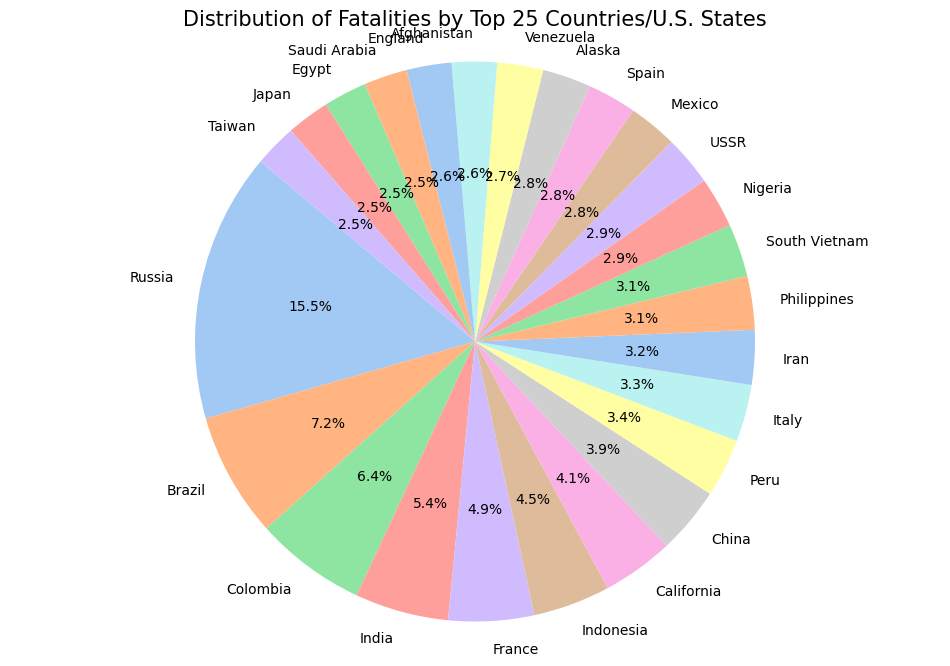

In [47]:
# Group by State_Country and sum the fatalities
location_stats = fatality_locations.groupby('State_Country')['Fatalities'].sum().sort_values(ascending=False)

# Selection of nodes and color codes
top_25_stats = location_stats.head(25)
colors = sns.color_palette('pastel')[0:25]

# Generate Pie Chart
plt.figure(figsize=(12, 8))
plt.pie(top_25_stats,
        labels=top_25_stats.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors)

plt.title('Distribution of Fatalities by Top 25 Countries/U.S. States', fontsize=15)
plt.axis('equal')

plt.show()